In [8]:
import numpy as np
import pandas as pd
import yaml

# Unit conversion
kJ_PER_MOL_TO_EV = 1.0 / 96.485   # 1 eV = 96.485 kJ/mol 

# Pure element DFT static energies (eV/atom)
E_static = {
    'Mg': -1.54928,    # eV/atom, DFT relaxed hcp-Mg
    'Zn': -1.034857,   # eV/atom, DFT relaxed hcp-Zn
}

# Intermetallic compound definitions
# n_Mg, n_Zn   : atoms of each element in ONE formula unit
# N_phonopy    : total atoms in the phonopy supercell
# dHf_static   : DFT static formation enthalpy (eV/atom), 0 K, no ZPE
# dat_file     : phonopy thermal_properties.dat file path
compounds = {
    'MgZn2': {
        'n_Mg': 1, 'n_Zn': 2,
        'N_phonopy': 12,
        'dHf_static': -0.1064,
        'dat_file': 'mgzn2_thermal_properties.dat',
    },
    'Mg4Zn7': {
        'n_Mg': 4, 'n_Zn': 7,
        'N_phonopy': 110,
        'dHf_static': -0.1016,
        'dat_file': 'mg4zn7_thermal_properties.dat',
    },
    'Mg21Zn25': {
        'n_Mg': 21, 'n_Zn': 25,
        'N_phonopy': 276,
        'dHf_static': -0.0890,
        'dat_file': 'mg21zn25_thermal_properties.dat',
    },
    'Mg51Zn20': {
        'n_Mg': 51, 'n_Zn': 20,
        'N_phonopy': 142,
        'dHf_static': -0.0280,
        'dat_file': 'mg51zn20_thermal_properties.dat',
    },
}

# Pure element phonon files
# phonopy yaml format; natom is read directly from the file
element_files = {
    'Mg': 'Mg_thermal_properties.yaml',
    'Zn': 'zn_thermal_properties.yaml',
}

# Load functions
def load_phonopy_yaml(filepath):
    with open(filepath) as f:
        data = yaml.safe_load(f)
    natom = data['natom']
    records = [
        {'T': tp['temperature'], 'F_vib_kJ': tp['free_energy']}
        for tp in data['thermal_properties']
    ]
    return natom, pd.DataFrame(records)


def load_phonopy_dat(filepath):
    records = []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line.startswith('#') or not line:
                continue
            cols = line.split()
            if len(cols) == 5:
                records.append({'T': float(cols[0]), 'F_vib_kJ': float(cols[1])})
    return pd.DataFrame(records)


# Load pure element vibrational free energies
print("Loading pure element phonon data...")
elem_data = {}
for elem, fpath in element_files.items():
    natom, df = load_phonopy_yaml(fpath)
    # Convert to eV/atom: divide by natom, then by 96.485
    df['F_vib_eV_per_atom'] = df['F_vib_kJ'] / natom * kJ_PER_MOL_TO_EV
    elem_data[elem] = df.set_index('T')['F_vib_eV_per_atom']
    print(f"  {elem}: natom={natom}, "
          f"ZPE={df['F_vib_eV_per_atom'].iloc[0]:.4f} eV/atom, "
          f"F(1000K)={df['F_vib_eV_per_atom'].iloc[-1]:.4f} eV/atom")

# Compute ΔGf(T) for each compound 
print("\nComputing ΔGf(T) for each compound...")
all_results = []

for name, info in compounds.items():
    n_Mg      = info['n_Mg']
    n_Zn      = info['n_Zn']
    N         = n_Mg + n_Zn        # atoms per formula unit
    x_Mg      = n_Mg / N           # Mg mole fraction
    x_Zn      = n_Zn / N           # Zn mole fraction
    N_phonopy = info['N_phonopy']  # atoms in phonopy supercell
    dHf       = info['dHf_static'] # static DFT ΔHf (eV/atom)

    # Load compound vibrational free energy
    df_cpd = load_phonopy_dat(info['dat_file'])
    df_cpd['F_vib_eV_per_atom'] = df_cpd['F_vib_kJ'] / N_phonopy * kJ_PER_MOL_TO_EV

    ZPE_cpd = df_cpd['F_vib_eV_per_atom'].iloc[0]
    ZPE_ref = x_Mg * elem_data['Mg'].iloc[0] + x_Zn * elem_data['Zn'].iloc[0]
    print(f"\n  {name}  (x_Mg={x_Mg:.4f}, x_Zn={x_Zn:.4f}, N_phonopy={N_phonopy})")
    print(f"    ZPE compound : {ZPE_cpd:.4f} eV/atom")
    print(f"    ZPE reference: {ZPE_ref:.4f} eV/atom")
    print(f"    ΔZPE         : {ZPE_cpd - ZPE_ref:+.4f} eV/atom")
    print(f"    ΔHf (static) : {dHf:+.4f} eV/atom")

    # ΔGf(T) = ΔHf_static + F_vib_cpd(T)/atom - x_Mg*F_vib_Mg(T)/atom - x_Zn*F_vib_Zn(T)/atom
    temps  = df_cpd['T'].values
    dGf    = np.zeros(len(temps))

    for i, (T, F_cpd_per_atom) in enumerate(zip(temps, df_cpd['F_vib_eV_per_atom'])):
        F_Mg = elem_data['Mg'].loc[T]
        F_Zn = elem_data['Zn'].loc[T]
        dF_vib = F_cpd_per_atom - x_Mg * F_Mg - x_Zn * F_Zn
        dGf[i] = dHf + dF_vib

    print(f"    ΔGf(0K)      : {dGf[0]:+.4f} eV/atom  (= ΔHf + ΔZPE)")
    print(f"    ΔGf(300K)    : {dGf[temps == 300][0]:+.4f} eV/atom")
    print(f"    ΔGf(1000K)   : {dGf[-1]:+.4f} eV/atom")

    for T, gf in zip(temps, dGf):
        all_results.append({
            'Compound':        name,
            'x_Zn':            round(x_Zn, 6),
            'T_K':             T,
            'dHf_static_eV':   dHf,
            'dGf_eV_per_atom': round(gf, 6),
        })

# Write output files
df_out = pd.DataFrame(all_results)

# 1. Full long-format CSV 
csv_long = 'gibbs_formation_energies.csv'
df_out.to_csv(csv_long, index=False)
print(f"\nSaved: {csv_long}")

# 2. Wide-format CSV
pivot = df_out.pivot(index='T_K', columns='Compound', values='dGf_eV_per_atom')
pivot.index.name = 'T_K'
csv_wide = 'gibbs_formation_energies_wide.csv'
pivot.to_csv(csv_wide)
print(f"Saved: {csv_wide}")

# 3. Summary table printed to terminal
print("\n" + "="*70)
print("ΔGf (eV/atom) summary at selected temperatures")
print("="*70)
summary_temps = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
print(pivot.loc[summary_temps].to_string(float_format=lambda x: f"{x:+.4f}"))
print("="*70)


Loading pure element phonon data...
  Mg: natom=2, ZPE=0.1574 eV/atom, F(1000K)=0.0574 eV/atom
  Zn: natom=2, ZPE=0.1932 eV/atom, F(1000K)=0.1172 eV/atom

Computing ΔGf(T) for each compound...

  MgZn2  (x_Mg=0.3333, x_Zn=0.6667, N_phonopy=12)
    ZPE compound : 0.1202 eV/atom
    ZPE reference: 0.1812 eV/atom
    ΔZPE         : -0.0611 eV/atom
    ΔHf (static) : -0.1064 eV/atom
    ΔGf(0K)      : -0.1675 eV/atom  (= ΔHf + ΔZPE)
    ΔGf(300K)    : -0.1737 eV/atom
    ΔGf(1000K)   : -0.2383 eV/atom

  Mg4Zn7  (x_Mg=0.3636, x_Zn=0.6364, N_phonopy=110)
    ZPE compound : 0.1227 eV/atom
    ZPE reference: 0.1801 eV/atom
    ΔZPE         : -0.0574 eV/atom
    ΔHf (static) : -0.1016 eV/atom
    ΔGf(0K)      : -0.1590 eV/atom  (= ΔHf + ΔZPE)
    ΔGf(300K)    : -0.1649 eV/atom
    ΔGf(1000K)   : -0.2258 eV/atom

  Mg21Zn25  (x_Mg=0.4565, x_Zn=0.5435, N_phonopy=276)
    ZPE compound : 0.1283 eV/atom
    ZPE reference: 0.1768 eV/atom
    ΔZPE         : -0.0486 eV/atom
    ΔHf (static) : -0.0890 

In [11]:
"""
ΔGf at 300 K for Mg-Zn intermetallics — manual input
======================================================
ΔGf(T) = ΔHf_static + F_vib_compound(T)/atom
                     - x_Mg * F_vib_Mg(T)/atom
                     - x_Zn * F_vib_Zn(T)/atom

F_vib (eV/atom) = F_vib (kJ/mol/cell) / N_atoms / 96.485
"""

# ── Conversion factor ─────────────────────────────────────────────────────────
kJ_to_eV = 1 / 96.485   # kJ/mol → eV

# ── F_vib at 300 K from phonopy files (kJ/mol per unit cell) ─────────────────
F_Mg_300K  = 29.8660365    # Mg,       N = 2 atoms
F_Zn_300K  = 36.9881101    # Zn,       N = 2 atoms
F_MgZn2    = 129.7082790   # MgZn2,    N = 12 atoms
F_Mg4Zn7   = 1220.2041528  # Mg4Zn7,   N = 110 atoms
F_Mg21Zn25 = 3223.8948912  # Mg21Zn25, N = 276 atoms
F_Mg51Zn20 = 1915.7417918  # Mg51Zn20, N = 142 atoms
F_Mg2Zn11 = 347.6530710 #Mg2Zn11, N=39 atoms

# ── Convert to eV/atom ────────────────────────────────────────────────────────
Mg  = F_Mg_300K  / 2   * kJ_to_eV
Zn  = F_Zn_300K  / 2   * kJ_to_eV
C1  = F_MgZn2    / 12  * kJ_to_eV
C2  = F_Mg4Zn7   / 110 * kJ_to_eV
C3  = F_Mg21Zn25 / 276 * kJ_to_eV
C4  = F_Mg51Zn20 / 142 * kJ_to_eV
C5  = F_Mg2Zn11 / 39 * kJ_to_eV

# ── ΔGf = ΔHf_static + F_vib_compound - x_Mg*F_vib_Mg - x_Zn*F_vib_Zn ──────
#         ΔHf       x_Mg    x_Zn
dGf_MgZn2    = -0.1064 + C1 - (1/3)*Mg  - (2/3)*Zn
dGf_Mg4Zn7   = -0.1016 + C2 - (4/11)*Mg - (7/11)*Zn
dGf_Mg21Zn25 = -0.0890 + C3 - (21/46)*Mg - (25/46)*Zn
dGf_Mg51Zn20 = -0.0280 + C4 - (51/71)*Mg - (20/71)*Zn
dGf_Mg2Zn11 =  -0.0119 + C5 - (6/39)*Mg - (33/39)*Zn

# ── Print results ─────────────────────────────────────────────────────────────
print(f"ΔGf at 300 K (eV/atom)")
print(f"  MgZn2    : {dGf_MgZn2:.4f}")
print(f"  Mg4Zn7   : {dGf_Mg4Zn7:.4f}")
print(f"  Mg21Zn25 : {dGf_Mg21Zn25:.4f}")
print(f"  Mg51Zn20 : {dGf_Mg51Zn20:.4f}")
print(f"  Mg2Zn11  : {dGf_Mg2Zn11:.4f}")

ΔGf at 300 K (eV/atom)
  MgZn2    : -0.1737
  Mg4Zn7   : -0.1649
  Mg21Zn25 : -0.1428
  Mg51Zn20 : -0.0533
  Mg2Zn11  : -0.1055


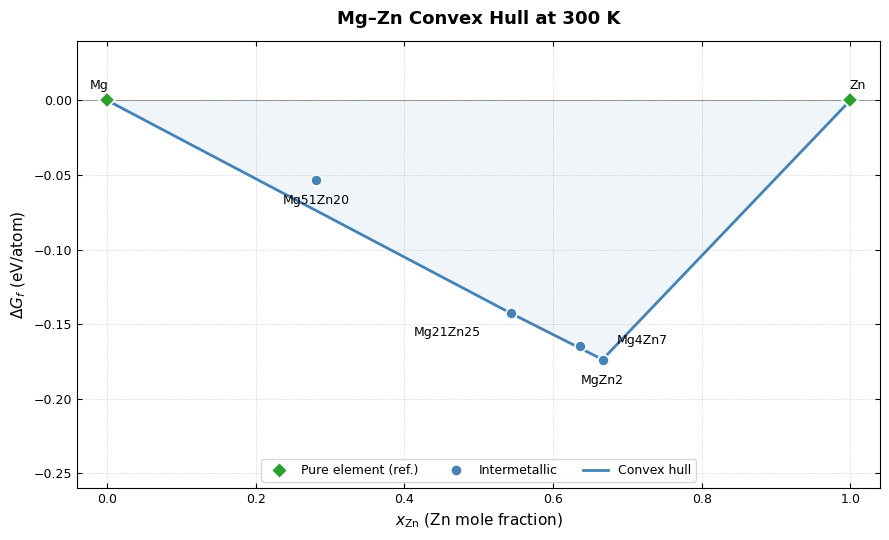

In [9]:
"""
Mg-Zn Convex Hull at 300 K
===========================
Plots the convex hull of Gibbs free energy of formation at 300 K
for Mg-Zn intermetallics, using the computed ΔGf values from
gibbs_formation_energies.csv.

Requires:
    - gibbs_formation_energies.csv (output from gibbs_formation_energy.py)
    - numpy, matplotlib, pandas
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── Load data and extract 300 K values ───────────────────────────────────────
df = pd.read_csv('gibbs_formation_energies.csv')
df_300 = df[df['T_K'] == 300.0][['Compound', 'x_Zn', 'dGf_eV_per_atom']]

# ── Build full point list including pure element references at ΔGf = 0 ───────
points = [('Mg', 0.0, 0.0)]
for _, row in df_300.iterrows():
    points.append((row['Compound'], row['x_Zn'], row['dGf_eV_per_atom']))
points.append(('Zn', 1.0, 0.0))

labels = [p[0] for p in points]
xs     = np.array([p[1] for p in points])
es     = np.array([p[2] for p in points])

# ── Sort by x_Zn ─────────────────────────────────────────────────────────────
idx    = np.argsort(xs)
xs_s   = xs[idx]
es_s   = es[idx]
labs_s = [labels[i] for i in idx]

# ── Lower convex hull ─────────────────────────────────────────────────────────
def lower_hull(pts):
    """
    Compute the lower convex hull of a set of (x, y) points.
    For a formation energy hull we want the lowest envelope,
    i.e. the most negative ΔGf at each composition.
    """
    hull = []
    for p in pts:
        while len(hull) >= 2:
            a, b = hull[-2], hull[-1]
            # Cross product: if not turning left, pop the last point
            cross = (b[0]-a[0])*(p[1]-a[1]) - (b[1]-a[1])*(p[0]-a[0])
            if cross <= 0:
                hull.pop()
            else:
                break
        hull.append(p)
    return hull

pts_sorted = list(zip(xs_s, es_s, labs_s))
hull       = lower_hull(pts_sorted)
hull_xs    = np.array([h[0] for h in hull])
hull_es    = np.array([h[1] for h in hull])

# ── Label offsets (dx, dy) in data coordinates ───────────────────────────────
offsets = {
    'Mg':        (-0.01,  0.010),
    'Mg51Zn20':  ( 0.00, -0.014),
    'Mg21Zn25':  (-0.04, -0.013),
    'Mg4Zn7':    ( 0.05,  0.004),
    'MgZn2':     ( 0.00, -0.014),
    'Zn':        ( 0.01,  0.010),
}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))

# Shaded area under hull
ax.fill_between(hull_xs, hull_es, 0, alpha=0.08, color='steelblue', zorder=0)

# Hull line
ax.plot(hull_xs, hull_es, color='steelblue', linewidth=2.0,
        solid_capstyle='round', solid_joinstyle='round', zorder=2)

# Data points and labels
for lbl, x, e in zip(labs_s, xs_s, es_s):
    is_ref = lbl in ('Mg', 'Zn')
    color  = '#2ca02c' if is_ref else 'steelblue'
    marker = 'D' if is_ref else 'o'

    ax.plot(x, e, marker=marker, color=color, markersize=8,
            markeredgecolor='white', markeredgewidth=1.2, zorder=5)

    dx, dy = offsets.get(lbl, (0, -0.013))
    ha = 'center'
    if dx > 0.01:  ha = 'left'
    if dx < -0.01: ha = 'right'
    ax.annotate(lbl, xy=(x, e), xytext=(x+dx, e+dy),
                fontsize=9, ha=ha, va='center', color='black')

# Axes
ax.set_xlim(-0.04, 1.04)
ax.set_ylim(-0.260, 0.040)
ax.set_xlabel('$x_{\\mathrm{Zn}}$ (Zn mole fraction)', fontsize=11)
ax.set_ylabel('$\\Delta G_f$ (eV/atom)', fontsize=11)
ax.set_title('Mg–Zn Convex Hull at 300 K', fontsize=13, fontweight='bold', pad=12)

ax.axhline(0, color='black', linewidth=0.6, linestyle='-', alpha=0.4)
ax.tick_params(direction='in', which='both', top=True, right=True, labelsize=9)
ax.grid(True, linestyle=':', linewidth=0.5, color='gray', alpha=0.5)

# Legend
legend_elements = [
    plt.Line2D([0],[0], marker='D', color='w', markerfacecolor='#2ca02c',
               markeredgecolor='white', markersize=8, label='Pure element (ref.)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
               markeredgecolor='white', markersize=8, label='Intermetallic'),
    plt.Line2D([0],[0], color='steelblue', linewidth=2, label='Convex hull'),
]
ax.legend(handles=legend_elements, fontsize=9, framealpha=0.9,
          edgecolor='lightgray', loc='lower center', ncol=3)

plt.tight_layout()
plt.savefig('convex_hull_300K.png', dpi=180, bbox_inches='tight')
plt.show()


In [12]:
"""
Script 1: Compute dGf(T) for Mg2Zn11 and update CSV files
==========================================================
Run this first to generate/update the CSV files.

Requires:
    - mg2zn11_thermal_properties.yaml
    - Mg_thermal_properties.yaml
    - zn_thermal_properties.yaml
    - gibbs_formation_energies.csv  (existing)
"""

import pandas as pd
import yaml

# ── Unit conversion ───────────────────────────────────────────────────────────
kJ_TO_EV = 1 / 96.485   # kJ/mol → eV

# ── Corrected static formation enthalpy (eV/atom) ────────────────────────────
dHf = -0.0119   # Mg2Zn11, using corrected Zn reference -1.0902006 eV/atom

# ── Load pure element F_vib from yaml ────────────────────────────────────────
def load_yaml(filepath):
    """Load phonopy yaml, return F_vib in eV/atom indexed by temperature."""
    with open(filepath) as f:
        data = yaml.safe_load(f)
    natom = data['natom']
    records = [{'T': tp['temperature'], 'F_vib_kJ': tp['free_energy']}
               for tp in data['thermal_properties']]
    df = pd.DataFrame(records)
    df['F_vib_eV_per_atom'] = df['F_vib_kJ'] / natom * kJ_TO_EV
    return df.set_index('T')['F_vib_eV_per_atom']

F_Mg = load_yaml('Mg_thermal_properties.yaml')
F_Zn = load_yaml('zn_thermal_properties.yaml')

# ── Compute dGf(T) for Mg2Zn11 ───────────────────────────────────────────────
with open('mg2zn11_thermal_properties.yaml') as f:
    data = yaml.safe_load(f)

natom  = data['natom']   # 39 atoms in phonopy cell
n_Mg   = 2
n_Zn   = 11
N_fu   = n_Mg + n_Zn    # 13 atoms per formula unit
x_Mg   = n_Mg / N_fu
x_Zn   = n_Zn / N_fu

print(f"Mg2Zn11: natom={natom}, x_Mg={x_Mg:.4f}, x_Zn={x_Zn:.4f}")

temps, dGf = [], []
for tp in data['thermal_properties']:
    T      = tp['temperature']
    F_cpd  = tp['free_energy'] / natom * kJ_TO_EV
    dF_vib = F_cpd - x_Mg * F_Mg.loc[T] - x_Zn * F_Zn.loc[T]
    temps.append(T)
    dGf.append(round(dHf + dF_vib, 6))

print(f"  dGf(0K)    = {dGf[0]:.4f} eV/atom")
print(f"  dGf(300K)  = {dGf[temps.index(300.0)]:.4f} eV/atom")
print(f"  dGf(1000K) = {dGf[-1]:.4f} eV/atom")

# ── Append to existing CSV ────────────────────────────────────────────────────
df_new = pd.DataFrame({
    'Compound':        'Mg2Zn11',
    'x_Zn':            round(x_Zn, 6),
    'T_K':             temps,
    'dHf_static_eV':   dHf,
    'dGf_eV_per_atom': dGf,
})

df_existing = pd.read_csv('gibbs_formation_energies.csv')
df_combined = pd.concat([df_existing, df_new], ignore_index=True)
df_combined.to_csv('gibbs_formation_energies.csv', index=False)
print(f"\nSaved: gibbs_formation_energies.csv")

# ── Update wide CSV ───────────────────────────────────────────────────────────
pivot = df_combined.pivot(index='T_K', columns='Compound', values='dGf_eV_per_atom')
pivot.index.name = 'T_K'
pivot.to_csv('gibbs_formation_energies_wide.csv')
print(f"Saved: gibbs_formation_energies_wide.csv")
print(f"\nCompounds in CSV: {sorted(df_combined['Compound'].unique())}")

Mg2Zn11: natom=39, x_Mg=0.1538, x_Zn=0.8462
  dGf(0K)    = -0.0952 eV/atom
  dGf(300K)  = -0.1055 eV/atom
  dGf(1000K) = -0.2001 eV/atom

Saved: gibbs_formation_energies.csv
Saved: gibbs_formation_energies_wide.csv

Compounds in CSV: ['Mg21Zn25', 'Mg2Zn11', 'Mg4Zn7', 'Mg51Zn20', 'MgZn2']


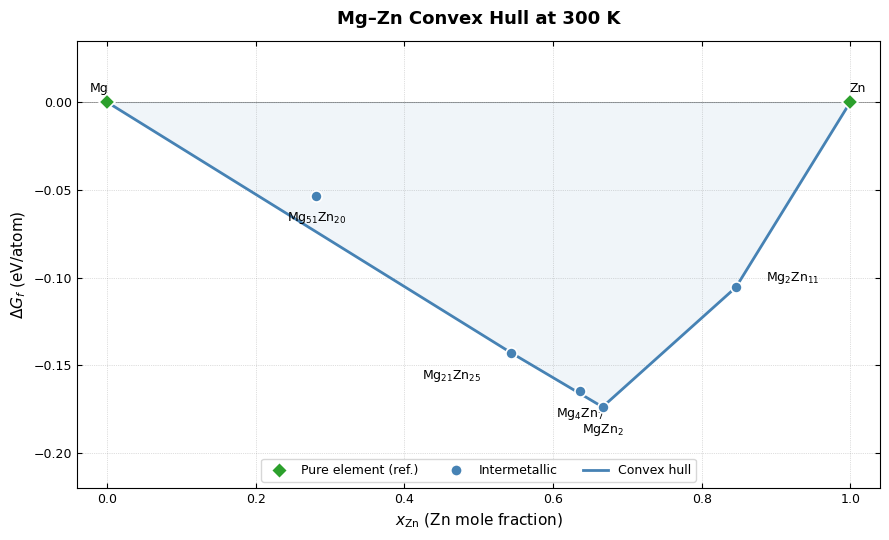

In [14]:
"""
Mg-Zn Convex Hull at 300 K
===========================
Plots convex hull of Gibbs free energy of formation at 300 K
for all 5 Mg-Zn intermetallics. Values manually input.
"""

import numpy as np
import matplotlib.pyplot as plt

# ── Data: (label, x_Zn, dGf eV/atom) ────────────────────────────────────────
points = [
    ('Mg',                   0.0,      0.0000),
    ('Mg$_{51}$Zn$_{20}$',  20/71,   -0.0533),
    ('Mg$_{21}$Zn$_{25}$',  25/46,   -0.1428),
    ('Mg$_4$Zn$_7$',         7/11,   -0.1649),
    ('MgZn$_2$',             2/3,    -0.1737),
    ('Mg$_2$Zn$_{11}$',     11/13,   -0.1055),
    ('Zn',                   1.0,     0.0000),
]

labels = [p[0] for p in points]
xs     = np.array([p[1] for p in points])
es     = np.array([p[2] for p in points])

# Sort by x_Zn
idx    = np.argsort(xs)
xs_s   = xs[idx]; es_s = es[idx]; labs_s = [labels[i] for i in idx]

# ── Lower convex hull ─────────────────────────────────────────────────────────
def lower_hull(pts):
    hull = []
    for p in pts:
        while len(hull) >= 2:
            a, b = hull[-2], hull[-1]
            cross = (b[0]-a[0])*(p[1]-a[1]) - (b[1]-a[1])*(p[0]-a[0])
            if cross <= 0: hull.pop()
            else: break
        hull.append(p)
    return hull

hull    = lower_hull(list(zip(xs_s, es_s, labs_s)))
hull_xs = np.array([h[0] for h in hull])
hull_es = np.array([h[1] for h in hull])

# ── Label offsets (dx, dy) in data coordinates ───────────────────────────────
offsets = {
    'Mg':                    (-0.01,  0.008),
    'Mg$_{51}$Zn$_{20}$':   ( 0.00, -0.013),
    'Mg$_{21}$Zn$_{25}$':   (-0.04, -0.013),
    'Mg$_4$Zn$_7$':         ( 0.00, -0.013),
    'MgZn$_2$':             ( 0.00, -0.013),
    'Mg$_2$Zn$_{11}$':      ( 0.04,  0.005),
    'Zn':                   ( 0.01,  0.008),
}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.fill_between(hull_xs, hull_es, 0, alpha=0.08, color='steelblue', zorder=0)
ax.plot(hull_xs, hull_es, color='steelblue', linewidth=2.0,
        solid_capstyle='round', solid_joinstyle='round', zorder=2)

for lbl, x, e in zip(labs_s, xs_s, es_s):
    is_ref = lbl in ('Mg', 'Zn')
    color  = '#2ca02c' if is_ref else 'steelblue'
    marker = 'D' if is_ref else 'o'
    ax.plot(x, e, marker=marker, color=color, markersize=8,
            markeredgecolor='white', markeredgewidth=1.2, zorder=5)
    dx, dy = offsets.get(lbl, (0, -0.013))
    ha = 'center'
    if dx > 0.01:  ha = 'left'
    if dx < -0.01: ha = 'right'
    ax.annotate(lbl, xy=(x, e), xytext=(x+dx, e+dy),
                fontsize=9, ha=ha, va='center', color='black')

ax.set_xlim(-0.04, 1.04)
ax.set_ylim(-0.220, 0.035)
ax.set_xlabel('$x_{\\mathrm{Zn}}$ (Zn mole fraction)', fontsize=11)
ax.set_ylabel('$\\Delta G_f$ (eV/atom)', fontsize=11)
ax.set_title('Mg–Zn Convex Hull at 300 K', fontsize=13, fontweight='bold', pad=12)
ax.axhline(0, color='black', linewidth=0.6, linestyle='-', alpha=0.4)
ax.tick_params(direction='in', which='both', top=True, right=True, labelsize=9)
ax.grid(True, linestyle=':', linewidth=0.5, color='gray', alpha=0.5)

legend_elements = [
    plt.Line2D([0],[0], marker='D', color='w', markerfacecolor='#2ca02c',
               markeredgecolor='white', markersize=8, label='Pure element (ref.)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
               markeredgecolor='white', markersize=8, label='Intermetallic'),
    plt.Line2D([0],[0], color='steelblue', linewidth=2, label='Convex hull'),
]
ax.legend(handles=legend_elements, fontsize=9, framealpha=0.9,
          edgecolor='lightgray', loc='lower center', ncol=3)

plt.tight_layout()
plt.savefig('convex_hull_300K_final.png', dpi=180, bbox_inches='tight')
plt.show()